In [1]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [3]:
# ============================================================================
# Section 2: Dataset Paths & Configuration
# ============================================================================

# Define Kaggle dataset paths
BASE_PATH = Path('/kaggle/input/datasets/swanjohi/breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset')

TRAIN_IMG_PATH = BASE_PATH / 'train' / 'images'
TRAIN_MASK_PATH = BASE_PATH / 'train' / 'masks'
TRAIN_CSV_PATH = BASE_PATH / 'train' / 'train.csv'

VAL_IMG_PATH = BASE_PATH / 'val' / 'images'
VAL_MASK_PATH = BASE_PATH / 'val' / 'masks'
VAL_CSV_PATH = BASE_PATH / 'val' / 'val.csv'

TEST_IMG_PATH = BASE_PATH / 'test' / 'images'
TEST_CSV_PATH = BASE_PATH / 'test' / 'test.csv'

SAMPLE_SUBMISSION_PATH = BASE_PATH / 'sample_submission.csv'

# SPARK-aligned configuration:
# - smaller model capacity for a small medical dataset
# - Dice-first optimization
# - cosine decay across the full run
CONFIG = {
    'image_size': 320,
    'batch_size': 8,
    'base_channels': 32,
    'learning_rate': 3e-4,
    'min_lr': 1e-6,
    'epochs': 160,
    'threshold': 0.45,
    'num_workers': 2,
    'loss_mode': 'dice',
    'dice_loss_weight': 0.7,
    'bce_loss_weight': 0.3,
    'use_amp': True,
    'grad_clip': 1.0,
    'early_stopping_patience': 20,
    'min_component_area': 64,
}

print(" Dataset Configuration:")
print(f"  Train images: {TRAIN_IMG_PATH}")
print(f"  Train masks: {TRAIN_MASK_PATH}")
print(f"  Val images: {VAL_IMG_PATH}")
print(f"  Test images: {TEST_IMG_PATH}")
print(f" Train df: {TRAIN_CSV_PATH}")
print("\n  Hyperparameters:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

 Dataset Configuration:
  Train images: /kaggle/input/datasets/swanjohi/breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/train/images
  Train masks: /kaggle/input/datasets/swanjohi/breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/train/masks
  Val images: /kaggle/input/datasets/swanjohi/breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/val/images
  Test images: /kaggle/input/datasets/swanjohi/breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/test/images
 Train df: /kaggle/input/datasets/swanjohi/breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/train/train.csv

  Hyperparameters:
  image_size: 320
  batch_size: 8
  base_channels: 32
  learning_rate: 0.0003
  min_lr: 1e-06
  epochs: 160
  threshold: 0.45
  num_workers: 2
  loss_mode: dice
  dice_loss_weight: 0.7
  bce_loss_weight: 0.3
  use_amp: True
  grad_clip: 1.0
  early_stopping_patience: 20
  min_component_area: 64


In [4]:
# ============================================================================
# Section 3: Load & Explore Data
# ============================================================================

# Load CSV files
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

print(" Training Set:")
print(f"  Shape: {train_df.shape}")
print(train_df.head())

print("\n Validation Set:")
print(f"  Shape: {val_df.shape}")
print(val_df.head())

print("\n Test Set:")
print(f"  Shape: {test_df.shape}")
print(test_df.head())

# Dataset statistics
print("\n Dataset Statistics:")
print(f"  Total train samples: {len(train_df)}")
print(f"  Total val samples: {len(val_df)}")
print(f"  Total test samples: {len(test_df)}")

# Class distribution in training set
if 'cls' in train_df.columns:
    print("\n  Training set class distribution:")
    print(train_df['cls'].value_counts())

# Lesion distribution
if 'has_lesion' in train_df.columns:
    print("\n Lesion distribution (training):")
    print(train_df['has_lesion'].value_counts())
    
# Source distribution
if 'source' in train_df.columns:
    print("\n Data source distribution (training):")
    print(train_df['source'].value_counts())


 Training Set:
  Shape: (427, 4)
            image_id     cls source  has_lesion
0  sp_train_0001.png  benign   BUSI           1
1  sp_train_0002.png  benign   BUSI           1
2  sp_train_0003.png  benign   BUSI           1
3  sp_train_0004.png  benign   BUSI           1
4  sp_train_0005.png  benign   BUSI           1

 Validation Set:
  Shape: (90, 4)
          image_id     cls source  has_lesion
0  sp_val_0001.png  benign   BUSI           1
1  sp_val_0002.png  benign   BUSI           1
2  sp_val_0003.png  benign   BUSI           1
3  sp_val_0004.png  benign   BUSI           1
4  sp_val_0005.png  benign   BUSI           1

 Test Set:
  Shape: (94, 1)
           image_id
0  sp_test_0001.png
1  sp_test_0002.png
2  sp_test_0003.png
3  sp_test_0004.png
4  sp_test_0005.png

 Dataset Statistics:
  Total train samples: 427
  Total val samples: 90
  Total test samples: 94

  Training set class distribution:
cls
benign       284
malignant    143
Name: count, dtype: int64

 Lesion distribution


Sample 1: sp_train_0001.png
  Image shape: (468, 567), values: [0, 255]
  Mask shape: (468, 567), values: [0, 255]
  Class: benign
  Has lesion: 1

Sample 2: sp_train_0002.png
  Image shape: (567, 669), values: [0, 243]
  Mask shape: (567, 669), values: [0, 255]
  Class: benign
  Has lesion: 1

Sample 3: sp_train_0003.png
  Image shape: (462, 561), values: [0, 255]
  Mask shape: (462, 561), values: [0, 255]
  Class: benign
  Has lesion: 1


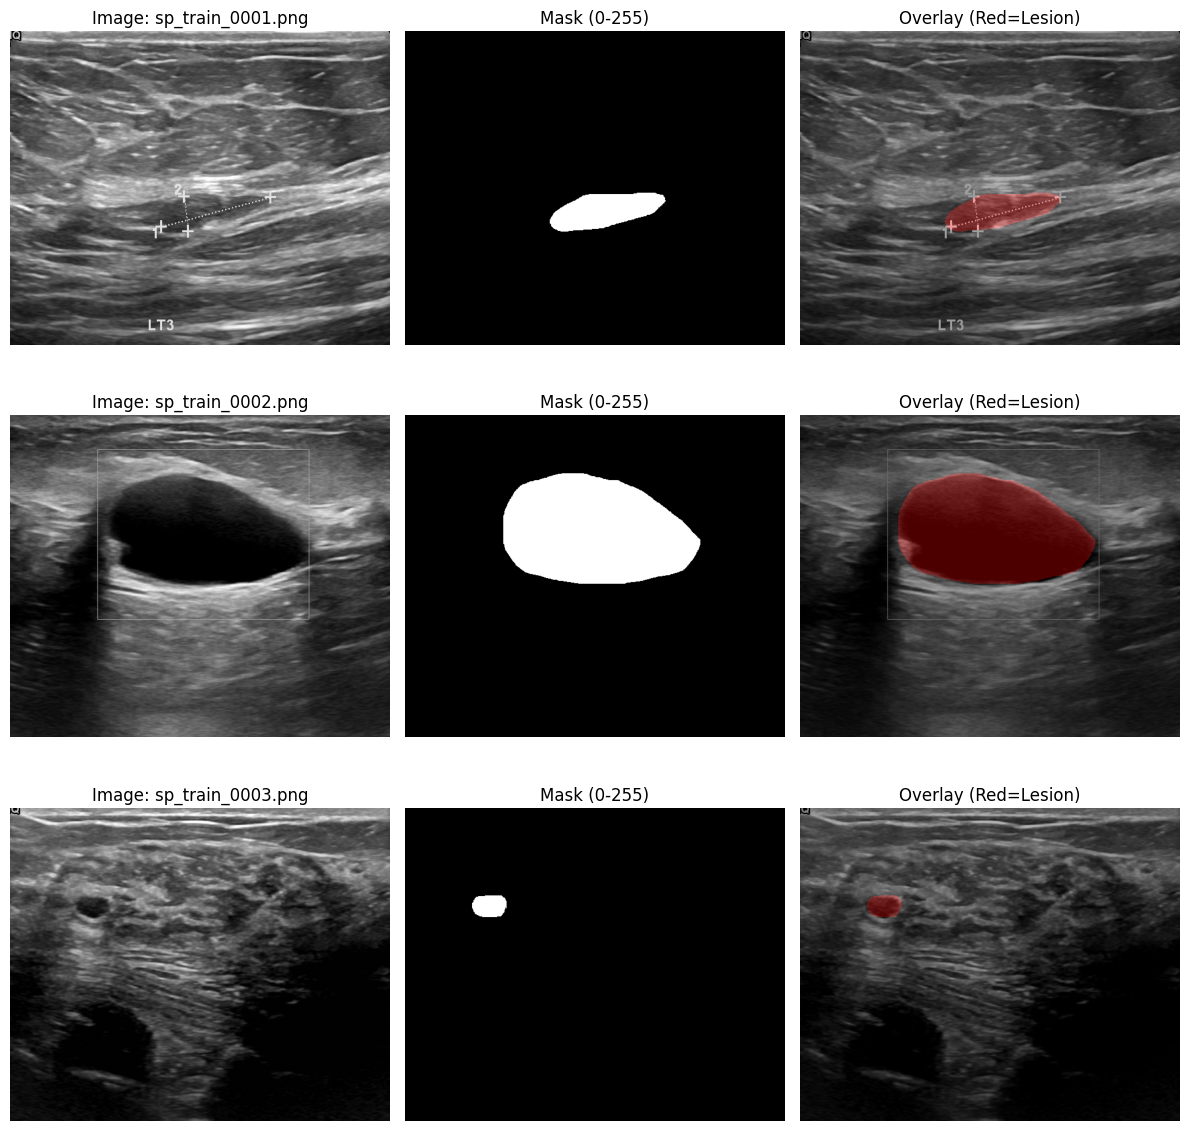

In [5]:
# ============================================================================
# Section 4: Dataset Visualization
# ============================================================================

def visualize_training_samples(df, img_path, mask_path, num_samples=5):
    """Visualize training samples with masks and overlays"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    
    for idx, (ax_row, sample_idx) in enumerate(zip(axes, range(num_samples))):
        image_id = df.iloc[sample_idx]['image_id']
        base_id = image_id.replace('.png', '') 
        
        # Load image and mask
        img_file = img_path / f"{base_id}.png"
        mask_file = mask_path / f"{base_id}_mask.png"
        
        if img_file.exists() and mask_file.exists():
            img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
            
            # Display image
            ax_row[0].imshow(img, cmap='gray')
            ax_row[0].set_title(f'Image: {image_id}')
            ax_row[0].axis('off')
            
            # Display mask
            ax_row[1].imshow(mask, cmap='gray')
            ax_row[1].set_title(f'Mask (0-255)')
            ax_row[1].axis('off')
            
            # Display overlay
            overlay = np.copy(img).astype(np.float32) / 255.0
            overlay_rgb = np.stack([overlay, overlay, overlay], axis=-1)
            mask_colored = np.zeros((overlay.shape[0], overlay.shape[1], 3))
            mask_colored[mask > 127] = [1, 0, 0]  # Red for lesion
            
            ax_row[2].imshow(overlay_rgb * 0.7 + mask_colored * 0.3)
            ax_row[2].set_title(f'Overlay (Red=Lesion)')
            ax_row[2].axis('off')
            
            # Print metadata
            print(f"\nSample {sample_idx + 1}: {image_id}")
            print(f"  Image shape: {img.shape}, values: [{img.min()}, {img.max()}]")
            print(f"  Mask shape: {mask.shape}, values: [{mask.min()}, {mask.max()}]")
            if 'cls' in df.columns:
                print(f"  Class: {df.iloc[sample_idx]['cls']}")
            if 'has_lesion' in df.columns:
                print(f"  Has lesion: {df.iloc[sample_idx]['has_lesion']}")
        else:
            print(f"  Files not found for {image_id}")
            if not img_file.exists():
                print(f"     Missing image: {img_file}")
            if not mask_file.exists():
                print(f"     Missing mask: {mask_file}")
    
    plt.tight_layout()
    plt.show()

# Visualize training samples
visualize_training_samples(train_df, TRAIN_IMG_PATH, TRAIN_MASK_PATH, num_samples=3)

In [6]:
# ============================================================================

def resize_with_aspect_ratio_and_pad(image, target_size=(320, 320), interpolation=cv2.INTER_LINEAR):
    """
    Resize an image without distorting lesion geometry, then pad to target size.
    """
    target_h, target_w = target_size
    original_h, original_w = image.shape[:2]

    scale = min(target_h / original_h, target_w / original_w)
    resized_h = max(1, int(round(original_h * scale)))
    resized_w = max(1, int(round(original_w * scale)))

    resized = cv2.resize(image, (resized_w, resized_h), interpolation=interpolation)

    pad_h = target_h - resized_h
    pad_w = target_w - resized_w

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    padded = cv2.copyMakeBorder(
        resized,
        top,
        bottom,
        left,
        right,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )

    resize_metadata = {
        'original_size': (original_h, original_w),
        'resized_size': (resized_h, resized_w),
        'pads': (top, bottom, left, right),
        'scale': scale,
    }

    return padded, resize_metadata


def preprocess_image(image, target_size=(320, 320)):
    """
    Preprocess image:
    1. Preserve aspect ratio
    2. Pad to target size
    3. Normalize to [0, 1]

    Returns:
        preprocessed_image: Normalized image
        resize_metadata: Information required to restore predictions
    """
    image, resize_metadata = resize_with_aspect_ratio_and_pad(
        image,
        target_size=target_size,
        interpolation=cv2.INTER_LINEAR
    )
    image = image.astype(np.float32) / 255.0
    return image, resize_metadata


def preprocess_mask(mask, resize_metadata):
    """
    Apply the exact same resize and padding strategy used for the image.
    """
    resized_h, resized_w = resize_metadata['resized_size']
    top, bottom, left, right = resize_metadata['pads']

    mask = cv2.resize(mask, (resized_w, resized_h), interpolation=cv2.INTER_NEAREST)
    mask = cv2.copyMakeBorder(
        mask,
        top,
        bottom,
        left,
        right,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )
    mask = (mask > 127).astype(np.float32)
    return mask


def restore_mask_to_original_size(mask, resize_metadata):
    """
    Remove padding and resize a predicted mask back to the source resolution.
    """
    original_h, original_w = resize_metadata['original_size']
    resized_h, resized_w = resize_metadata['resized_size']
    top, bottom, left, right = resize_metadata['pads']

    cropped = mask[top:top + resized_h, left:left + resized_w]
    restored = cv2.resize(
        cropped.astype(np.float32),
        (original_w, original_h),
        interpolation=cv2.INTER_LINEAR
    )
    return restored


# Verify preprocessing on a sample
base_id = train_df.iloc[0]['image_id'].replace('.png', '')
sample_img_path = TRAIN_IMG_PATH / f"{base_id}.png"
sample_mask_path = TRAIN_MASK_PATH / f"{base_id}_mask.png"

img_original = cv2.imread(str(sample_img_path), cv2.IMREAD_GRAYSCALE)
mask_original = cv2.imread(str(sample_mask_path), cv2.IMREAD_GRAYSCALE)

img_preprocessed, resize_metadata = preprocess_image(
    img_original,
    target_size=(CONFIG['image_size'], CONFIG['image_size'])
)
mask_preprocessed = preprocess_mask(mask_original, resize_metadata)
mask_restored = restore_mask_to_original_size(mask_preprocessed, resize_metadata)

print(" Preprocessing Verification:")
print(f"  Original image shape: {img_original.shape}")
print(f"  Target size: {(CONFIG['image_size'], CONFIG['image_size'])}")
print(f"  Resized image shape: {img_preprocessed.shape}")
print(f"  Resize metadata: {resize_metadata}")
print(f"  Preprocessed image range: [{img_preprocessed.min():.3f}, {img_preprocessed.max():.3f}]")
print(f"  Preprocessed mask unique values: {np.unique(mask_preprocessed)}")
print(f"  Restored mask shape: {mask_restored.shape}")

 Preprocessing Verification:
  Original image shape: (468, 567)
  Target size: (320, 320)
  Resized image shape: (320, 320)
  Resize metadata: {'original_size': (468, 567), 'resized_size': (264, 320), 'pads': (28, 28, 0, 0), 'scale': 0.564373897707231}
  Preprocessed image range: [0.000, 1.000]
  Preprocessed mask unique values: [0. 1.]
  Restored mask shape: (468, 567)


In [7]:
# ============================================================================
# Section 6: Data Augmentation with Albumentations
# ============================================================================

# Training augmentation pipeline tuned for ultrasound data.
# We avoid aggressive vertical flips / 90-degree rotations because they can
# create unrealistic anatomy, and instead favor mild geometric + intensity shifts.
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.Affine(
        translate_percent=0.05,
        scale=(0.9, 1.1),
        rotate=(-10, 10),
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        mask_value=0
    ),

    A.OneOf([
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=1.0
        ),
        A.RandomGamma(gamma_limit=(85, 115), p=1.0),
    ], p=0.45),

    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.GaussNoise(p=1.0),
    ], p=0.15),

    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),
    ToTensorV2(),
], is_check_shapes=False)

# Validation augmentation (deterministic, only normalization)
val_transform = A.Compose([
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),
    ToTensorV2(),
], is_check_shapes=False)

# Test augmentation (same as validation)
test_transform = A.Compose([
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=1.0),
    ToTensorV2(),
], is_check_shapes=False)

print(" Augmentation pipelines configured:")
print("  - Preserved realistic ultrasound geometry")
print("  - Added CLAHE / intensity shifts for domain robustness")
print("  - Kept validation/test transforms deterministic")

 Augmentation pipelines configured:
  - Preserved realistic ultrasound geometry
  - Added CLAHE / intensity shifts for domain robustness
  - Kept validation/test transforms deterministic


/tmp/ipykernel_23/478555196.py:11: UserWarning: Argument(s) 'value, mask_value' are not valid for transform Affine
  A.Affine(


In [8]:
# ============================================================================
# Section 7: Custom Dataset Class
# ============================================================================

class SegmentationDataset(Dataset):
    """Custom Dataset for image segmentation with image-mask pairs."""

    def __init__(self, df, img_path, mask_path=None, transform=None, img_size=(320, 320)):
        self.df = df
        self.img_path = Path(img_path)
        self.mask_path = Path(mask_path) if mask_path else None
        self.transform = transform
        self.img_size = img_size
        self.has_masks = mask_path is not None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.iloc[idx]['image_id']
        base_id = image_id.replace('.png', '')

        img_file = self.img_path / f"{base_id}.png"
        image = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {img_file}")

        image, resize_metadata = preprocess_image(image, target_size=self.img_size)

        if self.has_masks:
            mask_file = self.mask_path / f"{base_id}_mask.png"
            mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)

            if mask is None:
                raise FileNotFoundError(f"Mask not found: {mask_file}")

            mask = preprocess_mask(mask, resize_metadata)

            if self.transform:
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask']
            else:
                image = torch.from_numpy(np.expand_dims(image, 0)).float()
                mask = torch.from_numpy(np.expand_dims(mask, 0)).float()

            if mask.dim() == 2:
                mask = mask.unsqueeze(0)

            return image, mask

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        else:
            image = torch.from_numpy(np.expand_dims(image, 0)).float()

        original_h, original_w = resize_metadata['original_size']
        resized_h, resized_w = resize_metadata['resized_size']
        top, bottom, left, right = resize_metadata['pads']

        resize_metadata_tensor = torch.tensor(
            [original_h, original_w, resized_h, resized_w, top, bottom, left, right],
            dtype=torch.int64
        )

        return image, resize_metadata_tensor


# Test dataset instantiation
train_dataset = SegmentationDataset(
    train_df, TRAIN_IMG_PATH, TRAIN_MASK_PATH,
    transform=train_transform,
    img_size=(CONFIG['image_size'], CONFIG['image_size'])
)

print(f" Training dataset created with {len(train_dataset)} samples")

sample_image, sample_mask = train_dataset[0]
print(f"  Sample image shape: {sample_image.shape} (expected: [1, H, W])")
print(f"  Sample mask shape: {sample_mask.shape} (expected: [1, H, W])")
print(f"  Image dtype: {sample_image.dtype}, range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
print(f"  Mask dtype: {sample_mask.dtype}, range: [{sample_mask.min():.3f}, {sample_mask.max():.3f}]")

 Training dataset created with 427 samples
  Sample image shape: torch.Size([1, 320, 320]) (expected: [1, H, W])
  Sample mask shape: torch.Size([1, 320, 320]) (expected: [1, H, W])
  Image dtype: torch.float32, range: [0.000, 1.000]
  Mask dtype: torch.float32, range: [0.000, 1.000]


In [9]:

# Section 8: Create DataLoaders
# ============================================================================

# Create datasets
train_dataset = SegmentationDataset(
    train_df, TRAIN_IMG_PATH, TRAIN_MASK_PATH,
    transform=train_transform, img_size=(CONFIG['image_size'], CONFIG['image_size'])
)

val_dataset = SegmentationDataset(
    val_df, VAL_IMG_PATH, VAL_MASK_PATH,
    transform=val_transform, img_size=(CONFIG['image_size'], CONFIG['image_size'])
)

test_dataset = SegmentationDataset(
    test_df, TEST_IMG_PATH, mask_path=None,
    transform=test_transform, img_size=(CONFIG['image_size'], CONFIG['image_size'])
)

# Verify files exist before creating loaders
print(" Validating dataset files...")
missing_files = []


def validate_split(df, img_path, split_name, mask_path=None):
    split_missing = []
    for _, row in df.iterrows():
        base_id = row['image_id'].replace('.png', '')
        img_file = Path(img_path) / f"{base_id}.png"
        if not img_file.exists():
            split_missing.append(str(img_file))
        if mask_path is not None:
            mask_file = Path(mask_path) / f"{base_id}_mask.png"
            if not mask_file.exists():
                split_missing.append(str(mask_file))
    print(f"  {split_name}: checked {len(df)} metadata rows")
    return split_missing


missing_files.extend(validate_split(train_df, TRAIN_IMG_PATH, 'train', TRAIN_MASK_PATH))
missing_files.extend(validate_split(val_df, VAL_IMG_PATH, 'val', VAL_MASK_PATH))
missing_files.extend(validate_split(test_df, TEST_IMG_PATH, 'test'))

if missing_files:
    print(f" Missing {len(missing_files)} files:")
    for f in missing_files[:10]:
        print(f"   {f}")
else:
    print("All train/val/test files verified")

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(" DataLoaders created:")
print(f"  Train loader: {len(train_loader)} batches")
print(f"  Val loader: {len(val_loader)} batches")
print(f"  Test loader: {len(test_loader)} batches")

test_batch_images, test_batch_metadata = next(iter(test_loader))
print(f"  Test batch image tensor shape: {tuple(test_batch_images.shape)}")
print(f"  Test batch resize metadata tensor shape: {tuple(test_batch_metadata.shape)}")

 Validating dataset files...
  train: checked 427 metadata rows
  val: checked 90 metadata rows
  test: checked 94 metadata rows
All train/val/test files verified
 DataLoaders created:
  Train loader: 54 batches
  Val loader: 12 batches
  Test loader: 12 batches
  Test batch image tensor shape: (8, 1, 320, 320)
  Test batch resize metadata tensor shape: (8, 8)


In [10]:
# ============================================================================
# Section 9: U-Net Architecture Implementation
# ============================================================================

class DoubleConv(nn.Module):
    """Double Convolution Block: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU"""

    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class DownBlock(nn.Module):
    """Down Sampling Block: MaxPool -> DoubleConv"""

    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.down(x)


class UpBlock(nn.Module):
    """Up Sampling Block: ConvTranspose -> DoubleConv with skip connection"""

    def __init__(self, in_channels, out_channels):
        super(UpBlock, self).__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class UNet(nn.Module):
    """U-Net: encoder-decoder with skip connections and configurable width."""

    def __init__(self, in_channels=1, out_channels=1, base_channels=32):
        super(UNet, self).__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.down4 = DownBlock(base_channels * 8, base_channels * 16)

        self.up4 = UpBlock(base_channels * 16, base_channels * 8)
        self.up3 = UpBlock(base_channels * 8, base_channels * 4)
        self.up2 = UpBlock(base_channels * 4, base_channels * 2)
        self.up1 = UpBlock(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.down1(enc1)
        enc3 = self.down2(enc2)
        enc4 = self.down3(enc3)
        enc5 = self.down4(enc4)

        dec4 = self.up4(enc5, enc4)
        dec3 = self.up3(dec4, enc3)
        dec2 = self.up2(dec3, enc2)
        dec1 = self.up1(dec2, enc1)

        out = self.out_conv(dec1)
        return out


model = smp.Unet(
    encoder_name="resnet34",          # "efficientnet-b2 or "convnext_tiny" for higher scores
    encoder_weights="imagenet",       # Pretrained on ImageNet
    in_channels=1,                    # Ultrasound is grayscale; SMP auto-repeats to 3 channels
    classes=1,                        # Binary segmentation
    activation=None                   # Return raw logits for Dice/BCE loss
).to(device)



# model = UNet(
#     in_channels=1,
#     out_channels=1,
#     base_channels=CONFIG['base_channels']
# ).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# print(" Pretrained U-Net Model Created:")
# print(f"  Base channels: {CONFIG['base_channels']}")
# print(f"  Total parameters: {total_params:,}")
# print(f"  Trainable parameters: {trainable_params:,}")


print(" Pretrained U-Net with RESNET Created:")
print(f"  Backbone: resnet34 (ImageNet pretrained)")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")


# Verify shapes
test_input = torch.randn(
    2, 1, CONFIG['image_size'], CONFIG['image_size']
).to(device)
test_output = model(test_input)
print(f"  Test input shape: {test_input.shape}")
print(f"  Test output shape: {test_output.shape}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

 Pretrained U-Net with RESNET Created:
  Backbone: resnet34 (ImageNet pretrained)
  Total parameters: 24,430,097
  Trainable parameters: 24,430,097
  Test input shape: torch.Size([2, 1, 320, 320])
  Test output shape: torch.Size([2, 1, 320, 320])


In [11]:
# ============================================================================
# Section 10: Loss Functions & Metrics
# ============================================================================

def _ensure_4d_tensor(tensor):
    if tensor.dim() == 3:
        tensor = tensor.unsqueeze(1)
    return tensor.float()


def _prediction_to_probability(prediction):
    if prediction.max() > 1.0 or prediction.min() < 0.0:
        prediction = torch.sigmoid(prediction)
    return prediction


def dice_per_image(prediction, target, smooth=1e-6, threshold=None):
    """Compute Dice score per image, then return a tensor of shape [B]."""
    prediction = _ensure_4d_tensor(prediction)
    target = _ensure_4d_tensor(target)

    prediction = _prediction_to_probability(prediction)
    if threshold is not None:
        prediction = (prediction > threshold).float()

    dims = (1, 2, 3)
    intersection = (prediction * target).sum(dim=dims)
    denominator = prediction.sum(dim=dims) + target.sum(dim=dims)
    dice_scores = (2 * intersection + smooth) / (denominator + smooth)
    return dice_scores


def dice_coefficient(prediction, target, smooth=1e-6, threshold=None):
    """Mean Dice over the batch."""
    dice_scores = dice_per_image(prediction, target, smooth=smooth, threshold=threshold)
    return dice_scores.mean().item()


class DiceLoss(nn.Module):
    """Dice loss averaged per image instead of over the full flattened batch."""

    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, prediction, target):
        dice_scores = dice_per_image(prediction, target, smooth=self.smooth)
        return 1 - dice_scores.mean()


class CombinedLoss(nn.Module):
    """Fallback BCE + Dice loss for ablation experiments."""

    def __init__(self, bce_weight=0.3, dice_weight=0.7, smooth=1e-6):
        super(CombinedLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss(smooth=smooth)

    def forward(self, prediction, target):
        target = _ensure_4d_tensor(target)
        bce = self.bce_loss(prediction, target)
        dice = self.dice_loss(prediction, target)
        return self.bce_weight * bce + self.dice_weight * dice


def build_criterion(config):
    loss_mode = config.get('loss_mode', 'dice').lower()
    if loss_mode == 'dice':
        return DiceLoss(smooth=1e-6)
    if loss_mode == 'combined':
        return CombinedLoss(
            bce_weight=config['bce_loss_weight'],
            dice_weight=config['dice_loss_weight'],
            smooth=1e-6
        )
    raise ValueError(f"Unsupported loss_mode: {loss_mode}")


criterion = build_criterion(CONFIG)

print(" Loss functions configured:")
print(f"  Active loss: {CONFIG['loss_mode']}")
print("  Metric style: per-image mean Dice ")
print("  CombinedLoss retained as a fallback ablation option")

 Loss functions configured:
  Active loss: dice
  Metric style: per-image mean Dice 
  CombinedLoss retained as a fallback ablation option


In [12]:
# ============================================================================
# Section 11: Training Pipeline Setup
# ============================================================================

import gc
import torch
import torch.optim as optim

amp_enabled = CONFIG.get('use_amp', False) and device.type == 'cuda'
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['learning_rate']
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['epochs'],
    eta_min=CONFIG['min_lr']
)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_soft_dice': [],
    'val_hard_dice': [],
    'lr': [],
}

best_dice = float('-inf')
best_loss = float('inf')
output_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
best_model_path = str(output_dir / 'best_model_dice.pth')
best_loss_model_path = str(output_dir / 'best_model_loss.pth')


def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch using AMP and gradient clipping."""
    model.train()
    total_loss = 0.0
    num_batches = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()

        if CONFIG['grad_clip'] is not None and CONFIG['grad_clip'] > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches if num_batches > 0 else 0.0


def validate_epoch(model, loader, criterion, device, threshold):
    """Validate with both soft and thresholded Dice."""
    model.eval()
    total_loss = 0.0
    total_soft_dice = 0.0
    total_hard_dice = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=amp_enabled):
                logits = model(images)
                loss = criterion(logits, masks)

            soft_dice = dice_coefficient(logits, masks)
            hard_dice = dice_coefficient(logits, masks, threshold=threshold)

            total_loss += loss.item()
            total_soft_dice += soft_dice
            total_hard_dice += hard_dice
            num_batches += 1

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    avg_soft_dice = total_soft_dice / num_batches if num_batches > 0 else 0.0
    avg_hard_dice = total_hard_dice / num_batches if num_batches > 0 else 0.0

    return avg_loss, avg_soft_dice, avg_hard_dice


print("Training pipeline configured!")
print(f"Learning rate: {CONFIG['learning_rate']}")
print("Optimizer: Adam")
print("Scheduler: CosineAnnealingLR")
print(f"AMP enabled: {amp_enabled}")
print(f"Best Dice checkpoint: {best_model_path}")
print(f"Best loss checkpoint: {best_loss_model_path}")

Training pipeline configured!
Learning rate: 0.0003
Optimizer: Adam
Scheduler: CosineAnnealingLR
AMP enabled: True
Best Dice checkpoint: /kaggle/working/best_model_dice.pth
Best loss checkpoint: /kaggle/working/best_model_loss.pth


/tmp/ipykernel_23/2870072442.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


In [13]:
# ============================================================================
# Section 12: Train the Model
# ============================================================================

print(" Starting training...\n")

epochs_without_improvement = 0

for epoch in range(CONFIG['epochs']):
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    current_lr = optimizer.param_groups[0]['lr']

    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_soft_dice, val_hard_dice = validate_epoch(
        model,
        val_loader,
        criterion,
        device,
        threshold=CONFIG['threshold']
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_soft_dice'].append(val_soft_dice)
    history['val_hard_dice'].append(val_hard_dice)
    history['lr'].append(current_lr)

    improved_flags = []

    if val_hard_dice > best_dice + 1e-4:
        best_dice = val_hard_dice
        torch.save(model.state_dict(), best_model_path)
        improved_flags.append('best Dice')

    if val_loss < best_loss - 1e-4:
        best_loss = val_loss
        torch.save(model.state_dict(), best_loss_model_path)
        improved_flags.append('best loss')

    scheduler.step()

    if improved_flags:
        epochs_without_improvement = 0
        print(
            f" Epoch {epoch + 1}/{CONFIG['epochs']} - "
            f"{', '.join(improved_flags)} | "
            f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
            f"Val Soft Dice: {val_soft_dice:.4f}, Val Hard Dice: {val_hard_dice:.4f}, "
            f"LR: {current_lr:.2e}"
        )
    else:
        epochs_without_improvement += 1
        print(
            f"  Epoch {epoch + 1}/{CONFIG['epochs']} - "
            f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
            f"Val Soft Dice: {val_soft_dice:.4f}, Val Hard Dice: {val_hard_dice:.4f}, "
            f"LR: {current_lr:.2e}"
        )

    if epochs_without_improvement >= CONFIG['early_stopping_patience']:
        print(f"\n  Early stopping triggered at epoch {epoch + 1}.")
        break

print("\n Training completed!")
print(f"  Best validation Dice @ threshold {CONFIG['threshold']:.2f}: {best_dice:.4f}")
print(f"  Best validation loss: {best_loss:.4f}")
print(f"  Best Dice checkpoint: {best_model_path}")
print(f"  Best loss checkpoint: {best_loss_model_path}")

model.load_state_dict(torch.load(best_model_path, map_location=device))

 Starting training...



/tmp/ipykernel_23/2870072442.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/tmp/ipykernel_23/2870072442.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


 Epoch 1/160 - best Dice, best loss | Train Loss: 0.7515, Val Loss: 0.6414, Val Soft Dice: 0.3586, Val Hard Dice: 0.5473, LR: 3.00e-04
 Epoch 2/160 - best Dice, best loss | Train Loss: 0.6282, Val Loss: 0.5186, Val Soft Dice: 0.4814, Val Hard Dice: 0.5802, LR: 3.00e-04
 Epoch 3/160 - best Dice, best loss | Train Loss: 0.5226, Val Loss: 0.4530, Val Soft Dice: 0.5470, Val Hard Dice: 0.6313, LR: 3.00e-04
 Epoch 4/160 - best Dice, best loss | Train Loss: 0.4234, Val Loss: 0.3965, Val Soft Dice: 0.6035, Val Hard Dice: 0.6435, LR: 3.00e-04
 Epoch 5/160 - best Dice, best loss | Train Loss: 0.3628, Val Loss: 0.3560, Val Soft Dice: 0.6440, Val Hard Dice: 0.6767, LR: 3.00e-04
 Epoch 6/160 - best loss | Train Loss: 0.3206, Val Loss: 0.3524, Val Soft Dice: 0.6476, Val Hard Dice: 0.6680, LR: 2.99e-04
 Epoch 7/160 - best Dice, best loss | Train Loss: 0.3136, Val Loss: 0.2866, Val Soft Dice: 0.7134, Val Hard Dice: 0.7286, LR: 2.99e-04
  Epoch 8/160 - Train Loss: 0.2812, Val Loss: 0.3450, Val Soft Dic

<All keys matched successfully>

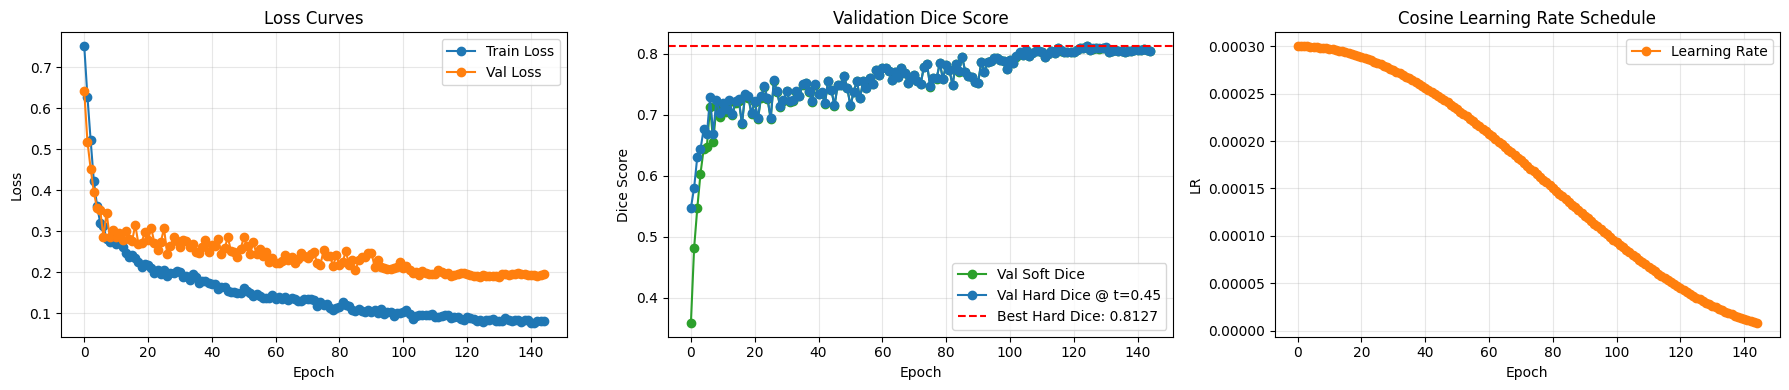

 Training Summary:
  Final train loss: 0.0825
  Final val loss: 0.1948
  Final val soft Dice: 0.8052
  Final val hard Dice: 0.8053
  Best val hard Dice: 0.8127 (epoch 125)
  Best val loss: 0.1874


In [14]:
# ============================================================================
# Section 13: Visualize Training Progress
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_soft_dice'], label='Val Soft Dice', marker='o', color='tab:green')
axes[1].plot(history['val_hard_dice'], label=f"Val Hard Dice @ t={CONFIG['threshold']:.2f}", marker='o', color='tab:blue')
axes[1].axhline(y=best_dice, color='red', linestyle='--', label=f'Best Hard Dice: {best_dice:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], label='Learning Rate', marker='o', color='tab:orange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_title('Cosine Learning Rate Schedule')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(history['val_hard_dice'])) + 1

print(" Training Summary:")
print(f"  Final train loss: {history['train_loss'][-1]:.4f}")
print(f"  Final val loss: {history['val_loss'][-1]:.4f}")
print(f"  Final val soft Dice: {history['val_soft_dice'][-1]:.4f}")
print(f"  Final val hard Dice: {history['val_hard_dice'][-1]:.4f}")
print(f"  Best val hard Dice: {best_dice:.4f} (epoch {best_epoch})")
print(f"  Best val loss: {best_loss:.4f}")

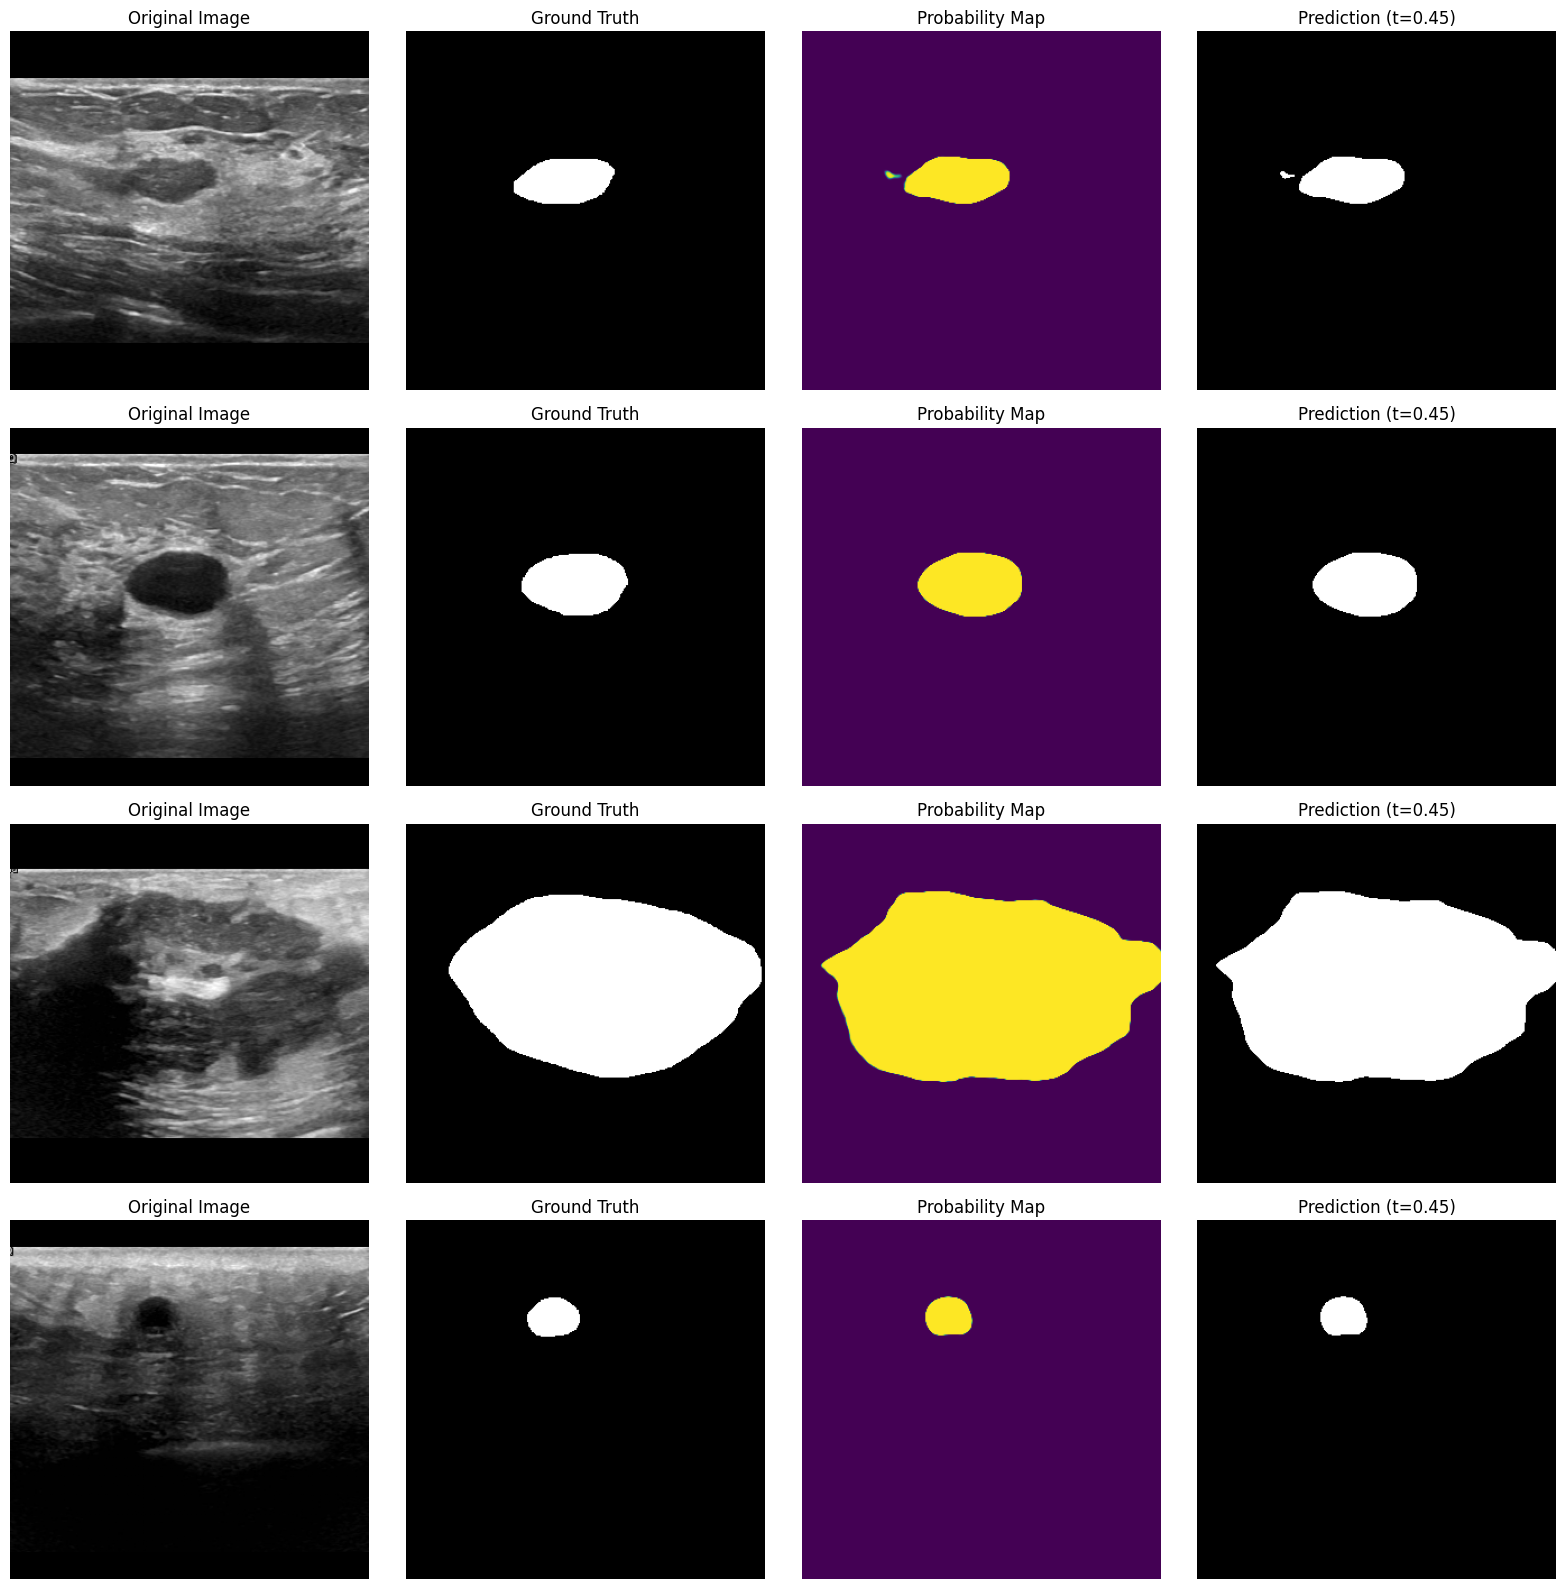

 Validation predictions visualized


In [15]:
# ============================================================================
# Section 14: Validation Predictions
# ============================================================================

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def visualize_predictions(model, loader, num_samples=5, threshold=CONFIG['threshold']):
    """Visualize predictions vs ground truth."""
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    model.eval()
    sample_count = 0

    with torch.no_grad():
        for images, masks in loader:
            if sample_count >= num_samples:
                break

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            batch_size = images.shape[0]

            for b in range(min(batch_size, num_samples - sample_count)):
                ax_row = axes[sample_count]

                img = images[b, 0].cpu().numpy()
                ax_row[0].imshow(img, cmap='gray')
                ax_row[0].set_title('Original Image')
                ax_row[0].axis('off')

                mask = masks[b, 0].cpu().numpy()
                ax_row[1].imshow(mask, cmap='gray')
                ax_row[1].set_title('Ground Truth')
                ax_row[1].axis('off')

                prob = probs[b, 0].cpu().numpy()
                ax_row[2].imshow(prob, cmap='viridis')
                ax_row[2].set_title('Probability Map')
                ax_row[2].axis('off')

                pred = preds[b, 0].cpu().numpy()
                ax_row[3].imshow(pred, cmap='gray')
                ax_row[3].set_title(f'Prediction (t={threshold})')
                ax_row[3].axis('off')

                sample_count += 1

    plt.tight_layout()
    plt.show()


visualize_predictions(model, val_loader, num_samples=4, threshold=CONFIG['threshold'])
print(" Validation predictions visualized")


 Testing different thresholds on validation set:

  Post-processing minimum component area: 64 pixels



/tmp/ipykernel_23/1578859243.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


  Threshold: 0.30 → Dice: 0.8147
  Threshold: 0.35 → Dice: 0.8151
  Threshold: 0.40 → Dice: 0.8151
  Threshold: 0.45 → Dice: 0.8150
  Threshold: 0.50 → Dice: 0.8149
  Threshold: 0.55 → Dice: 0.8149
  Threshold: 0.60 → Dice: 0.8149
  Threshold: 0.65 → Dice: 0.8149

✨ Optimal threshold: 0.35
   Optimal Dice: 0.8151


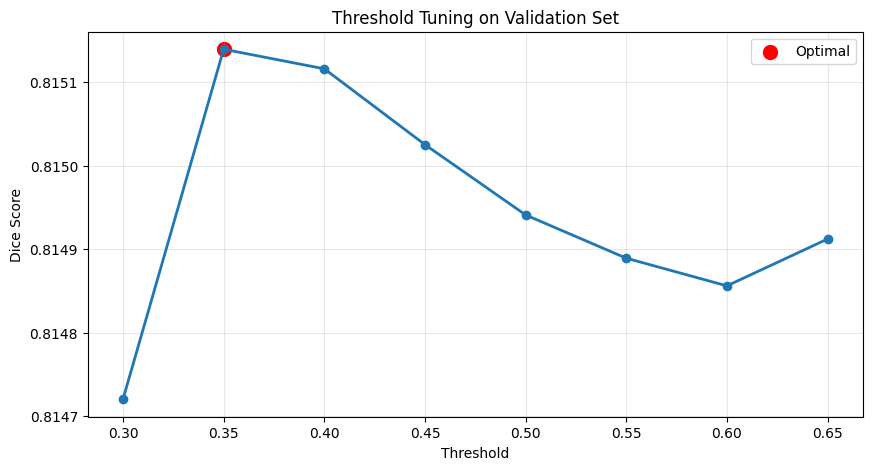

In [16]:
# ============================================================================
# Section 15: Threshold Tuning
# ============================================================================

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def post_process_mask(binary_mask, min_component_area=64, keep_largest=True):
    """Remove tiny false positives from a binary mask."""
    binary_mask = binary_mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
    if num_labels <= 1:
        return binary_mask

    valid_components = []
    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_component_area:
            valid_components.append((label, area))

    if not valid_components:
        return np.zeros_like(binary_mask, dtype=np.uint8)

    if keep_largest:
        valid_components = [max(valid_components, key=lambda item: item[1])]

    cleaned = np.zeros_like(binary_mask, dtype=np.uint8)
    for label, _ in valid_components:
        cleaned[labels == label] = 1

    return cleaned


def evaluate_threshold(model, loader, threshold, device):
    """Evaluate Dice score at a specific threshold after post-processing."""
    model.eval()
    total_dice = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=amp_enabled):
                logits = model(images)

            probs = torch.sigmoid(logits).float().squeeze(1).cpu().numpy().astype(np.float32, copy=False)

            processed_predictions = []
            for prob_map in probs:
                pred_mask = (prob_map > threshold).astype(np.uint8)
                pred_mask = post_process_mask(
                    pred_mask,
                    min_component_area=CONFIG['min_component_area'],
                    keep_largest=True
                )
                processed_predictions.append(pred_mask)

            processed_predictions = torch.from_numpy(
                np.asarray(processed_predictions, dtype=np.float32)
            ).unsqueeze(1).to(device)

            dice = dice_coefficient(processed_predictions, masks)
            total_dice += dice
            num_batches += 1

    return total_dice / num_batches if num_batches > 0 else 0.0


thresholds = np.arange(0.30, 0.70, 0.05)
dice_scores = []

print()
print(" Testing different thresholds on validation set:")
print()
print(f"  Post-processing minimum component area: {CONFIG['min_component_area']} pixels")
print()

for threshold in thresholds:
    dice = evaluate_threshold(model, val_loader, threshold, device)
    dice_scores.append(dice)
    print(f"  Threshold: {threshold:.2f} → Dice: {dice:.4f}")

optimal_idx = np.argmax(dice_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_dice = dice_scores[optimal_idx]

print()
print(f"✨ Optimal threshold: {optimal_threshold:.2f}")
print(f"   Optimal Dice: {optimal_dice:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, dice_scores, marker='o', linewidth=2)
plt.scatter([optimal_threshold], [optimal_dice], color='red', s=100, label='Optimal')
plt.xlabel('Threshold')
plt.ylabel('Dice Score')
plt.title('Threshold Tuning on Validation Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
# ============================================================================
# Section 16: Inference on Test Set
# ============================================================================

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()


def normalize_resize_metadata(metadata):
    """Convert batched resize metadata into a list of 8-value tuples."""
    if isinstance(metadata, torch.Tensor):
        if metadata.ndim == 1:
            metadata = metadata.unsqueeze(0)
        return [tuple(int(v) for v in row) for row in metadata.cpu().tolist()]

    if isinstance(metadata, np.ndarray):
        if metadata.ndim == 1:
            metadata = metadata[None, :]
        return [tuple(int(v) for v in row) for row in metadata.tolist()]

    if isinstance(metadata, (list, tuple)):
        if len(metadata) == 0:
            return []
        if all(isinstance(v, (int, np.integer)) for v in metadata):
            return [tuple(int(v) for v in metadata)]

        normalized = []
        for row in metadata:
            if isinstance(row, torch.Tensor):
                row = row.detach().cpu().tolist()
            elif isinstance(row, np.ndarray):
                row = row.tolist()
            normalized.append(tuple(int(v) for v in row))
        return normalized

    raise TypeError(f"Unsupported resize metadata container: {type(metadata)}")


def predict_with_tta(model, images, use_tta=True):
    """Average predictions from the original image and a horizontal flip."""
    with torch.cuda.amp.autocast(enabled=amp_enabled):
        logits = model(images)
        probs = torch.sigmoid(logits)

        if use_tta:
            flipped_images = torch.flip(images, dims=[3])
            flipped_logits = model(flipped_images)
            flipped_probs = torch.sigmoid(flipped_logits)
            probs = 0.5 * (probs + torch.flip(flipped_probs, dims=[3]))

    return probs.float()


def restore_prediction_to_original_size(prob_map, resize_metadata, threshold):
    """Undo padding, resize back to the original resolution, and post-process."""
    original_h, original_w, resized_h, resized_w, top, bottom, left, right = resize_metadata

    prob_map = np.asarray(prob_map, dtype=np.float32)
    cropped = prob_map[top:top + resized_h, left:left + resized_w]

    if cropped.size == 0:
        raise ValueError(
            f"Empty crop encountered during mask restoration. "
            f"prob_map shape={prob_map.shape}, metadata={resize_metadata}"
        )

    restored = cv2.resize(cropped, (original_w, original_h), interpolation=cv2.INTER_LINEAR)
    binary_mask = (restored > threshold).astype(np.uint8)
    binary_mask = post_process_mask(
        binary_mask,
        min_component_area=CONFIG['min_component_area'],
        keep_largest=True
    )
    return binary_mask


def predict_test_set(model, dataset, loader, threshold, device, use_tta=True):
    """Generate exactly one cleaned prediction per test image."""
    model.eval()
    predictions = []

    print(" Running inference on test set...")
    print(f"  TTA enabled: {use_tta}")

    with torch.no_grad():
        for batch_idx, (images, metadata) in enumerate(loader, start=1):
            images = images.to(device, non_blocking=True)
            batch_metadata = normalize_resize_metadata(metadata)
            probs = predict_with_tta(model, images, use_tta=use_tta)
            probs = probs.squeeze(1).cpu().numpy().astype(np.float32, copy=False)

            if len(probs) != len(batch_metadata):
                raise ValueError(
                    f"Batch {batch_idx} produced {len(probs)} probability maps but "
                    f"{len(batch_metadata)} metadata rows."
                )

            for prob_map, resize_meta in zip(probs, batch_metadata):
                predictions.append(
                    restore_prediction_to_original_size(prob_map, resize_meta, threshold)
                )

            print(
                f"  Batch {batch_idx}: added {len(probs)} predictions "
                f"(running total: {len(predictions)}/{len(dataset)})"
            )

    if len(predictions) != len(dataset):
        raise ValueError(
            f"Inference generated {len(predictions)} masks for {len(dataset)} test images."
        )

    return predictions


test_predictions = predict_test_set(
    model,
    test_dataset,
    test_loader,
    optimal_threshold,
    device,
    use_tta=True
)

predicted_positive = sum(int(pred_mask.sum() > 0) for pred_mask in test_predictions)

print(f" Generated {len(test_predictions)} predictions")
print(f"   First prediction shape: {test_predictions[0].shape}")
print(f"   Unique values: {np.unique(test_predictions[0])}")
print(f"   Predicted positive masks: {predicted_positive}/{len(test_predictions)}")

 Running inference on test set...
  TTA enabled: True


/tmp/ipykernel_23/348879748.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


  Batch 1: added 8 predictions (running total: 8/94)
  Batch 2: added 8 predictions (running total: 16/94)
  Batch 3: added 8 predictions (running total: 24/94)
  Batch 4: added 8 predictions (running total: 32/94)
  Batch 5: added 8 predictions (running total: 40/94)
  Batch 6: added 8 predictions (running total: 48/94)
  Batch 7: added 8 predictions (running total: 56/94)
  Batch 8: added 8 predictions (running total: 64/94)
  Batch 9: added 8 predictions (running total: 72/94)
  Batch 10: added 8 predictions (running total: 80/94)
  Batch 11: added 8 predictions (running total: 88/94)
  Batch 12: added 6 predictions (running total: 94/94)
 Generated 94 predictions
   First prediction shape: (465, 554)
   Unique values: [0 1]
   Predicted positive masks: 94/94


In [18]:
# ============================================================================
# Section 17: RLE Encoding Implementation
# ============================================================================

def rle_encode(mask):
    """
    Encode binary mask to RLE string using column-major (Fortran) order.
    
    Args:
        mask: Binary numpy array [H, W] with values 0 or 1
    
    Returns:
        RLE string: space-separated pairs of (pixel_start, run_length)
        Empty string if no positive pixels
    """
    # Flatten in column-major order (Fortran order)
    flat_mask = mask.astype(np.uint8).flatten('F')
    
    # Find all pixel positions where mask is 1
    pixel_positions = np.where(flat_mask == 1)[0]
    
    # If no positive pixels, return empty string
    if len(pixel_positions) == 0:
        return ""
    
    # Build RLE encoding
    rle_parts = []
    start = pixel_positions[0]
    
    for i in range(len(pixel_positions) - 1):
        current = pixel_positions[i]
        next_pixel = pixel_positions[i + 1]
        
        # If gap detected, save current run
        if next_pixel != current + 1:
            duration = current - start + 1
            rle_parts.append(f"{start + 1} {duration}")  # Pixel positions are 1-indexed
            start = next_pixel
    
    # Handle last run
    duration = pixel_positions[-1] - start + 1
    rle_parts.append(f"{start + 1} {duration}")  # Pixel positions are 1-indexed
    
    return " ".join(rle_parts)


def rle_decode(rle_string, shape):
    """
    Decode RLE string back to binary mask (for verification).
    
    Args:
        rle_string: RLE encoded string
        shape: Target shape (H, W)
    
    Returns:
        Binary mask [H, W]
    """
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    
    if len(rle_string) == 0:
        return mask.reshape(shape, order='F')
    
    pairs = rle_string.split()
    for i in range(0, len(pairs), 2):
        start = int(pairs[i]) - 1  # Convert to 0-indexed
        length = int(pairs[i + 1])
        mask[start:start + length] = 1
    
    return mask.reshape(shape, order='F')


# Test RLE encoding
test_mask = np.zeros((4, 4), dtype=np.float32)
test_mask[:2, :2] = 1  # Top-left 2×2

rle_encoded = rle_encode(test_mask)
rle_decoded = rle_decode(rle_encoded, test_mask.shape)

print(" RLE Encoding Verification:")
print(f"  Original mask:\n{test_mask.astype(int)}")
print(f"  RLE string: {rle_encoded}")
print(f"  Decoded:\n{rle_decoded.reshape(4, 4)}")
print(f"  Match: {np.array_equal(test_mask, rle_decoded.reshape(4, 4))}")

# Test empty mask
empty_mask = np.zeros((256, 256), dtype=np.float32)
empty_rle = rle_encode(empty_mask)
print(f"\n  Empty mask RLE: '{empty_rle}' (should be empty)")

 RLE Encoding Verification:
  Original mask:
[[1 1 0 0]
 [1 1 0 0]
 [0 0 0 0]
 [0 0 0 0]]
  RLE string: 1 2 5 2
  Decoded:
[[1 1 0 0]
 [1 1 0 0]
 [0 0 0 0]
 [0 0 0 0]]
  Match: True

  Empty mask RLE: '' (should be empty)


In [19]:
# ============================================================================
# Section 18: Create Submission File
# ============================================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path

# --------------------------------------------------------------------------
# Sanity check: number of predictions must match number of test samples
# --------------------------------------------------------------------------
num_test_images = len(test_df)
num_predictions = len(test_predictions)

print(" Checking submission inputs...")
print(f"  Number of test images   : {num_test_images}")
print(f"  Number of predictions   : {num_predictions}")

if num_test_images != num_predictions:
    raise ValueError(
        f"Mismatch detected: test_df contains {num_test_images} images, "
        f"but test_predictions contains {num_predictions} predicted masks. "
        f"You must generate exactly one prediction per test image before "
        f"creating the submission file."
    )

# --------------------------------------------------------------------------
# Encode all predictions to RLE
# --------------------------------------------------------------------------
rle_masks = []

print()
print(" Encoding predictions to RLE...")
print()

for idx, (image_id, pred_mask) in enumerate(zip(test_df['image_id'].values, test_predictions)):
    pred_mask = np.asarray(pred_mask)
    binary_mask = (pred_mask > 0).astype(np.uint8)
    rle_string = rle_encode(binary_mask)
    rle_masks.append(rle_string)

    if idx < 5:
        lesion_pixels = int(np.sum(binary_mask))
        print(f"  {image_id}: {lesion_pixels} lesion pixels → RLE length: {len(rle_string)}")

print()
print(" All predictions encoded")

# --------------------------------------------------------------------------
# Create submission DataFrame
# --------------------------------------------------------------------------
if SAMPLE_SUBMISSION_PATH.exists():
    submission_df = pd.read_csv(SAMPLE_SUBMISSION_PATH)
    if len(submission_df) != num_test_images:
        raise ValueError(
            f"sample_submission.csv contains {len(submission_df)} rows, expected {num_test_images}."
        )
else:
    submission_df = pd.DataFrame({'image_id': test_df['image_id'].values})

submission_df['image_id'] = test_df['image_id'].values
submission_df['rle_mask'] = rle_masks
submission_df = submission_df[['image_id', 'rle_mask']]

# --------------------------------------------------------------------------
# Verify submission format
# --------------------------------------------------------------------------
print()
print(" Submission DataFrame Preview:")
print(submission_df.head(10))

# --------------------------------------------------------------------------
# Submission statistics
# --------------------------------------------------------------------------
empty_count = (submission_df['rle_mask'] == '').sum()
non_empty_count = (submission_df['rle_mask'] != '').sum()

print()
print(" Submission Statistics:")
print(f"  Total samples         : {len(submission_df)}")
print(f"  Samples with lesion   : {non_empty_count}")
print(f"  Samples without lesion: {empty_count}")

# --------------------------------------------------------------------------
# Save submission
# --------------------------------------------------------------------------
output_dir = Path('/kaggle/working')
if not output_dir.exists():
    output_dir = Path.cwd()

submission_path = output_dir / 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print()
print(f" Submission saved to: {submission_path}")
print(f"  File size: {os.path.getsize(submission_path) / 1024:.2f} KB")

 Checking submission inputs...
  Number of test images   : 94
  Number of predictions   : 94

 Encoding predictions to RLE...

  sp_test_0001.png: 110485 lesion pixels → RLE length: 6992
  sp_test_0002.png: 173087 lesion pixels → RLE length: 6860
  sp_test_0003.png: 6030 lesion pixels → RLE length: 1248
  sp_test_0004.png: 13211 lesion pixels → RLE length: 2147
  sp_test_0005.png: 5707 lesion pixels → RLE length: 1007

 All predictions encoded

 Submission DataFrame Preview:
           image_id                                           rle_mask
0  sp_test_0001.png  23944 3 23965 6 24407 7 24429 10 24871 9 24893...
1  sp_test_0002.png  38734 1 39308 5 39882 9 40457 11 41029 17 4160...
2  sp_test_0003.png  119157 7 119619 16 120081 20 120545 24 121008 ...
3  sp_test_0004.png  205283 8 205859 11 206436 13 207012 17 207589 ...
4  sp_test_0005.png  70732 13 71309 15 71885 20 72461 24 73037 28 7...
5  sp_test_0006.png  67175 8 67576 14 67979 16 68381 20 68784 22 69...
6  sp_test_0007.png  18